# Pseudospectral Methods, Part II: Advanced Topics

Building on Part I (Fourier and Chebyshev differentiation, Clenshaw–Curtis quadrature, BVPs, the
heat equation, and the harmonic oscillator), this notebook tackles four practical extensions you
will hit the moment you try to use pseudospectral methods on a real problem:

1. **Mapping** the standard interval $[-1,1]$ onto an arbitrary or even unbounded domain.
2. **Two-dimensional** problems via tensor products: the 2D Poisson equation.
3. **Stiff nonlinear PDEs**: the KdV equation, soliton interactions, and integrating-factor RK4.
4. **The Gibbs phenomenon** and **exponential filters** for non-smooth data.

A short closing section sketches where to go next (spectral elements).

In [1]:
import numpy as np
import scipy.linalg as la
import scipy.integrate as si
import matplotlib.pyplot as plt
from matplotlib import cm

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})


# --- Reproduce the cheb(N) helper from Part I ------------------------------
def cheb(N):
    '''Chebyshev-Gauss-Lobatto points and differentiation matrix on [-1, 1].
    Trefethen, Spectral Methods in MATLAB, Program 1.
    Returns x with x[0] = 1, x[N] = -1.'''
    if N == 0:
        return np.array([[0.0]]), np.array([1.0])
    x = np.cos(np.pi * np.arange(N + 1) / N)
    c = np.ones(N + 1); c[0] = 2.0; c[N] = 2.0
    c = c * (-1.0) ** np.arange(N + 1)
    X = np.tile(x, (N + 1, 1)).T
    dX = X - X.T
    D = np.outer(c, 1.0 / c) / (dX + np.eye(N + 1))
    D = D - np.diag(D.sum(axis=1))
    return D, x

## 1. Working on arbitrary intervals — and unbounded domains

The standard Chebyshev grid lives on $[-1,1]$. To work on $[a,b]$, $[0,\infty)$, or $(-\infty,\infty)$
we use a smooth invertible map $x = g(\xi)$ with $\xi \in [-1,1]$.

### 1a. Affine map $[-1,1]\to[a,b]$

$$
x = \frac{b-a}{2}\xi + \frac{b+a}{2},\qquad \frac{dx}{d\xi}=\frac{b-a}{2}.
$$

So if $D$ is the standard CGL differentiation matrix on $\xi$, the differentiation matrix in $x$ is
just $D_x = \tfrac{2}{b-a}\, D$.

### 1b. Algebraic map for the half-line $[0,\infty)$

A standard choice is

$$
x = L\,\frac{1+\xi}{1-\xi},\qquad \frac{dx}{d\xi}=\frac{2L}{(1-\xi)^2}.
$$

so $\xi = -1\Leftrightarrow x = 0$ and $\xi = 1\Leftrightarrow x = \infty$. The "scale parameter" $L$
controls where the grid resolution is concentrated; a good rule of thumb is to pick $L$ on the
order of the natural decay length of the problem.

The chain rule says

$$
\frac{d}{dx} = \frac{1}{g'(\xi)}\frac{d}{d\xi} = \frac{(1-\xi)^2}{2L}\frac{d}{d\xi}.
$$

Crucially, $g'(\xi)\to\infty$ at $\xi = 1$ — i.e. the prefactor $(1-\xi)^2/(2L)\to 0$ at the
"infinity" boundary. That is *not a bug*: a function that decays at infinity has a vanishing
derivative there, and the metric factor enforces that automatically.

### Example: $-u''(x) + u(x) = e^{-x}$, $u(0)=1$, $u(x)\to 0$ as $x\to\infty$

Closed-form solution: $u(x) = e^{-x}\!\left(1 + \tfrac{x}{2}\right)$.

Plan:

1. Build $D$ on $\xi\in[-1,1]$.
2. Form $D_x = \mathrm{diag}((1-\xi)^2/2L)\,D$.
3. Form $D_{xx} = D_x\,D_x$.
4. Build the operator $A = -D_{xx} + I$, RHS $f = e^{-x}$.
5. Overwrite the row for $\xi=-1$ with $u(0)=1$ and the row for $\xi=+1$ with $u(\infty)=0$.

Note that `cheb(N)` returns $\xi$ in *decreasing* order: $\xi_0 = 1$ (i.e. $x = \infty$) and
$\xi_N = -1$ (i.e. $x = 0$).

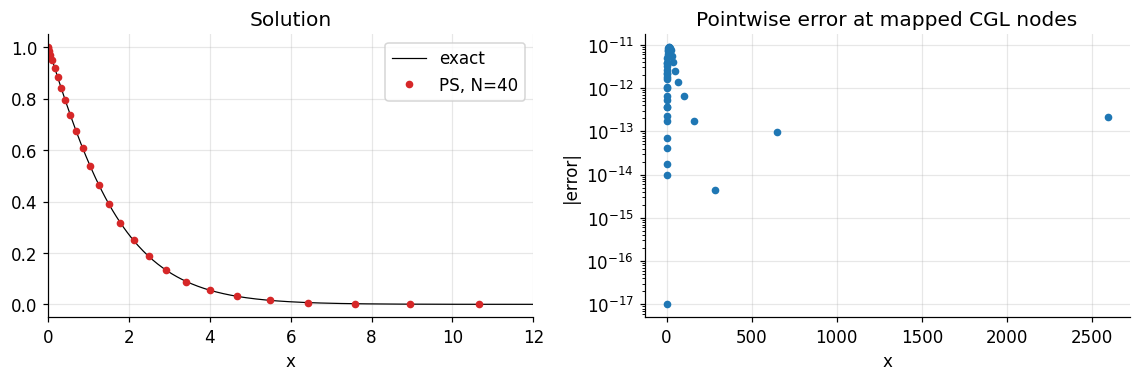

max |error| (finite nodes) at N=40, L=4: 8.75e-12


In [2]:
def solve_semiinf(N, L=4.0):
    '''Solve -u'' + u = exp(-x), u(0)=1, u(inf)=0 on [0, inf) via algebraic mapping.'''
    D, xi = cheb(N)                       # xi[0] = 1 (=> x = inf), xi[N] = -1 (=> x = 0)
    c = (1 - xi) ** 2 / (2 * L)            # dxi/dx
    Dx = np.diag(c) @ D
    Dxx = Dx @ Dx
    A = -Dxx + np.eye(N + 1)

    # x values, handling xi=1 specially (x = infinity)
    x = np.empty_like(xi)
    x[1:] = L * (1 + xi[1:]) / (1 - xi[1:])
    x[0] = np.inf

    # Build RHS, then overwrite boundary rows.
    f = np.where(np.isinf(x), 0.0, np.exp(-x))
    b = f.copy()

    # Row 0: xi=1 (x=infty) -> u = 0
    A[0, :] = 0.0; A[0, 0] = 1.0; b[0] = 0.0
    # Row N: xi=-1 (x=0)    -> u = 1
    A[-1, :] = 0.0; A[-1, -1] = 1.0; b[-1] = 1.0

    u = np.linalg.solve(A, b)
    return x, u


x, u = solve_semiinf(N=40, L=4.0)
u_exact_finite = lambda xx: np.exp(-xx) * (1 + xx / 2)

# Plot finite portion only.
finite = np.isfinite(x)
xs = np.linspace(0, 12, 400)
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.6))
ax[0].plot(xs, u_exact_finite(xs), "k-", lw=0.8, label="exact")
ax[0].plot(x[finite], u[finite], "o", color="C3", ms=4, label="PS, N=40")
ax[0].set_xlim(0, 12); ax[0].set_xlabel("x"); ax[0].set_title("Solution")
ax[0].legend()

err = np.abs(u[finite] - u_exact_finite(x[finite]))
ax[1].semilogy(x[finite], np.maximum(err, 1e-17), "o", color="C0", ms=4)
ax[1].set_xlabel("x"); ax[1].set_ylabel("|error|")
ax[1].set_title("Pointwise error at mapped CGL nodes")
plt.tight_layout(); plt.show()

print(f"max |error| (finite nodes) at N=40, L=4: {np.max(err):.2e}")

### Convergence study and the role of $L$

The scale parameter $L$ matters: too small and the grid wastes nodes outside the support of $u$,
too large and the few nodes near $x=0$ are stretched too thin. A short scan over $L$ shows the
sweet spot.

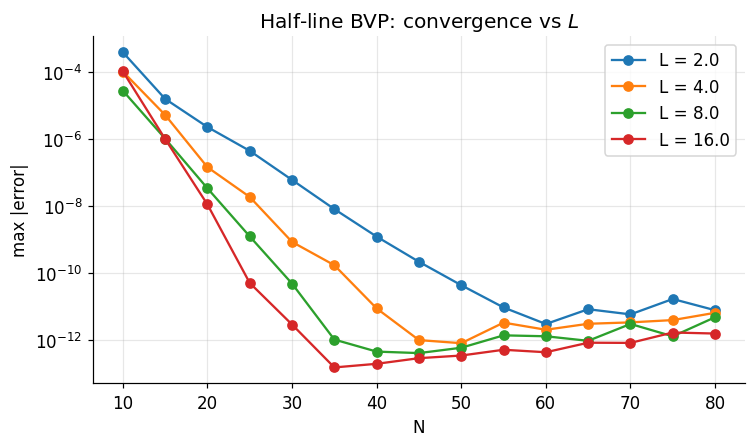

In [3]:
Ns = np.arange(10, 81, 5)
Ls = [2.0, 4.0, 8.0, 16.0]

fig, ax = plt.subplots(figsize=(7, 4.2))
for L in Ls:
    errs = []
    for N in Ns:
        x, u = solve_semiinf(N, L=L)
        finite = np.isfinite(x)
        err = np.max(np.abs(u[finite] - u_exact_finite(x[finite])))
        errs.append(max(err, 1e-17))
    ax.semilogy(Ns, errs, "o-", label=f"L = {L}")
ax.set_xlabel("N"); ax.set_ylabel("max |error|")
ax.set_title(r"Half-line BVP: convergence vs $L$")
ax.legend(); plt.tight_layout(); plt.show()

$L\approx 4$ is best here because the solution's natural scale is $\sim 1$ and the algebraic
map clusters resolution where it's needed. With $L$ tuned, we hit machine precision by $N\approx 40$
on a problem posed on the entire half-line — without ever truncating the domain.

For the doubly-infinite line $(-\infty,\infty)$, two well-known choices are:

* **Hermite functions** $\psi_n(x) = H_n(x)\,e^{-x^2/2}$ — natural for Gaussian-decaying solutions
  (e.g. Schrödinger with confining potential).
* **Rational Chebyshev** $TB_n(x) = T_n(\xi(x))$ with $\xi = x/\sqrt{1+x^2}$ — natural for
  algebraic decay.

Boyd's book has thorough chapters on both.

## 2. Two-dimensional problems by tensor products

For a tensor-product domain like $[-1,1]^2$, the natural grid is just the outer product of two CGL
grids. If $U_{ij} = u(x_j, y_i)$ is the matrix of nodal values (with $i$ indexing rows / $y$ and
$j$ indexing columns / $x$), then

$$
\frac{\partial u}{\partial x}\bigg|_{(x_j, y_i)} \approx (U D^T)_{ij},\qquad
\frac{\partial u}{\partial y}\bigg|_{(x_j, y_i)} \approx (D U)_{ij},
$$

where $D$ is the 1D Chebyshev differentiation matrix. So 2D differentiation is just two matrix
multiplies — we never form an $(N+1)^2\times(N+1)^2$ Jacobian for differentiation alone.

### 2D Poisson: $-\Delta u = f$ on $[-1,1]^2$ with $u = 0$ on $\partial\Omega$

For the *linear solve* we do need the global operator. Vectorize $U$ in row-major order
($\mathrm{vec}_C(U)_{i\cdot M + j} = U_{ij}$) and you can verify

$$
\mathrm{vec}(D U) = (D\otimes I)\,\mathrm{vec}(U),\qquad
\mathrm{vec}(U D^T) = (I\otimes D)\,\mathrm{vec}(U),
$$

so the discrete Laplacian on the interior is $L = D^2_\mathrm{int}\!\otimes I + I\otimes D^2_\mathrm{int}$,
where $D^2_\mathrm{int}$ is $D^2$ with first/last rows and columns removed (homogeneous Dirichlet).

### Manufactured solution

Pick

$$
u_\mathrm{exact}(x,y) = (1-x^2)(1-y^2)\,e^{x+y},
$$

which vanishes on $\partial\Omega$ exactly. A short calculation gives

$$
-\Delta u_\mathrm{exact} = e^{x+y}\!\left[(1-y^2)(1+x^2+4x) + (1-x^2)(1+y^2+4y)\right].
$$

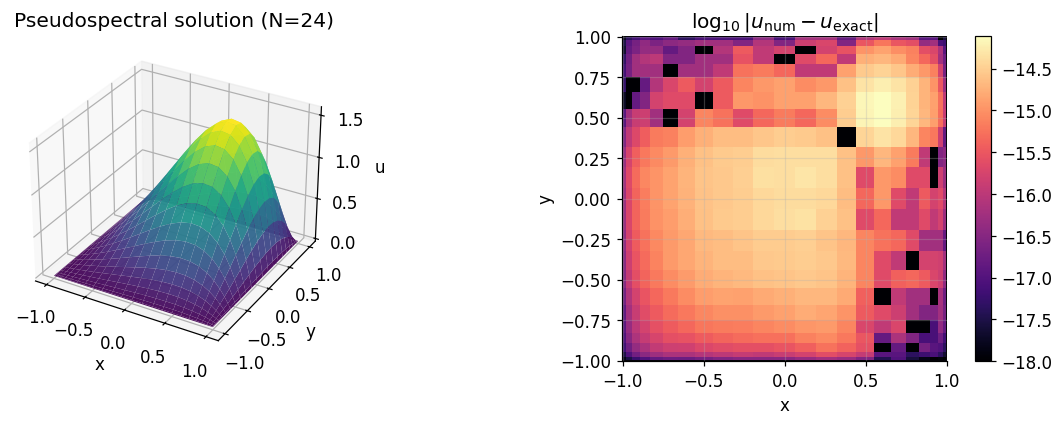

max |error| at N = 24: 7.77e-15


In [4]:
def u_exact_2d(x, y):
    return (1 - x**2) * (1 - y**2) * np.exp(x + y)


def f_2d(x, y):
    return np.exp(x + y) * (
        (1 - y**2) * (1 + x**2 + 4 * x)
        + (1 - x**2) * (1 + y**2 + 4 * y)
    )


def solve_poisson_2d(N):
    D, xi = cheb(N)
    D2 = D @ D
    D2i = D2[1:-1, 1:-1]                           # interior block
    Ni = N - 1                                     # interior count per dim
    I = np.eye(Ni)
    Lop = np.kron(D2i, I) + np.kron(I, D2i)        # discrete Laplacian on interior

    Xint = xi[1:-1]
    X, Y = np.meshgrid(Xint, Xint, indexing="xy")  # X[i,j]=Xint[j], Y[i,j]=Xint[i]
    F = f_2d(X, Y)

    Uint_vec = np.linalg.solve(-Lop, F.ravel())
    Uint = Uint_vec.reshape(Ni, Ni)

    U = np.zeros((N + 1, N + 1))
    U[1:-1, 1:-1] = Uint
    return xi, U


N = 24
xi, U = solve_poisson_2d(N)
X, Y = np.meshgrid(xi, xi, indexing="xy")
Uref = u_exact_2d(X, Y)

fig = plt.figure(figsize=(11, 4))

ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot_surface(X, Y, U, cmap=cm.viridis, edgecolor="none", alpha=0.95)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("u")
ax.set_title(f"Pseudospectral solution (N={N})")

ax2 = fig.add_subplot(1, 2, 2)
err = np.abs(U - Uref)
im = ax2.pcolormesh(X, Y, np.log10(err + 1e-18), cmap="magma", shading="auto")
ax2.set_xlabel("x"); ax2.set_ylabel("y")
ax2.set_title(r"$\log_{10}|u_{\rm num}-u_{\rm exact}|$")
ax2.set_aspect("equal")
plt.colorbar(im, ax=ax2)
plt.tight_layout(); plt.show()

print(f"max |error| at N = {N}: {np.max(err):.2e}")

### Convergence

We expect spectral convergence in $N$, with the linear-solve cost growing like $\mathcal{O}(N^6)$
for a dense direct solver on $(N-1)^2$ unknowns. (For larger problems, exploit the tensor structure
via a fast diagonalization solver — eigendecompose $D^2_\mathrm{int}$ once, then each Poisson solve
costs $\mathcal{O}(N^3)$.)

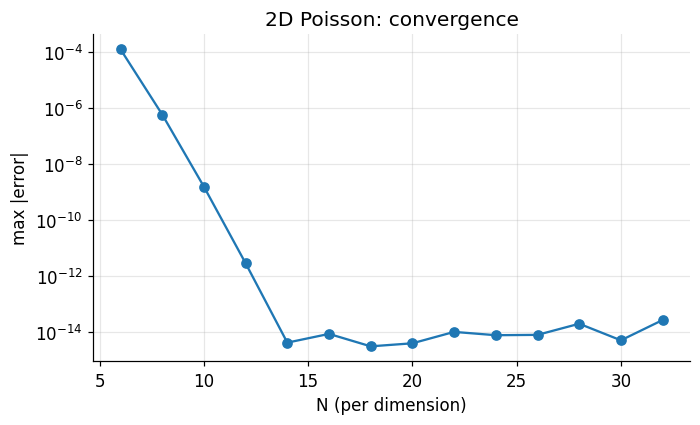

In [5]:
Ns = np.arange(6, 33, 2)
errs = []
for N in Ns:
    xi, U = solve_poisson_2d(N)
    X, Y = np.meshgrid(xi, xi, indexing="xy")
    errs.append(np.max(np.abs(U - u_exact_2d(X, Y))))

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.semilogy(Ns, np.maximum(errs, 1e-17), "o-")
ax.set_xlabel("N (per dimension)"); ax.set_ylabel("max |error|")
ax.set_title("2D Poisson: convergence")
plt.tight_layout(); plt.show()

Standard story: geometric convergence until roundoff, then a slight drift up because $D^2$
has condition number $\mathcal{O}(N^4)$ and we're stacking it with itself.

### Fast diagonalization (sketch)

Since $L_\mathrm{2D} = D^2\otimes I + I\otimes D^2$, and $D^2$ has eigendecomposition $D^2 = V\Lambda V^{-1}$,
the system $L U_\mathrm{2D}\,\mathrm{vec}(U) = \mathrm{vec}(F)$ becomes diagonal in the
$V\otimes V$ basis. The cost drops from $\mathcal{O}(N^6)$ to $\mathcal{O}(N^3)$ — same as a
1D solve, three times. This is the trick that makes large 2D/3D Chebyshev solvers practical.

## 3. Stiff nonlinear PDE: KdV via integrating-factor RK4

The Korteweg–de Vries equation

$$
u_t + u\,u_x + u_{xxx} = 0
$$

is the canonical test case for spectral methods on a nonlinear evolution PDE. It is *stiff* because
the linear dispersive term $u_{xxx}$ contributes an eigenvalue $\mathrm{i}k^3$ which forces an
explicit Euler step size $\Delta t \lesssim 1/k_{\max}^3$.

The fix: in Fourier space, $u_{xxx}$ is just multiplication by $-\mathrm{i}k^3$, so we can
**integrate the linear part exactly** and only treat the nonlinear part with an explicit scheme.

### Integrating factor

Write $\hat u_t = \hat L\hat u + \hat N(\hat u)$ with $\hat L = \mathrm{i}k^3$ and
$\hat N(\hat u) = -\tfrac{1}{2}\mathrm{i}k\widehat{u^2}$. Set $\hat v = e^{-\hat L t}\,\hat u$;
then $\hat v_t = e^{-\hat L t}\hat N(e^{\hat L t}\hat v)$, which is non-stiff. Apply RK4 to $\hat v$.

The clean implementation (Trefethen, *Spectral Methods in MATLAB*, Program 27) uses the half-step
shift $E = e^{\hat L\Delta t/2}$ as a building block:

In [6]:
def kdv_step_ifrk4(v_hat, dt, k, ik3, dealias_mask):
    '''One IFRK4 step for u_t + u u_x + u_xxx = 0 in Fourier space.
    Adapted from Trefethen, SMM, Program 27.'''
    g = -0.5j * dt * k                           # nonlinear-stage prefactor
    E = np.exp(dt * ik3 / 2)                     # half-step linear propagator
    E2 = E * E                                   # full-step linear propagator

    def n(vh):
        u = np.real(np.fft.ifft(vh * dealias_mask))
        return g * np.fft.fft(u**2) * dealias_mask

    a = n(v_hat)
    b = n(E * (v_hat + a / 2))
    c = n(E * v_hat + b / 2)
    d = n(E2 * v_hat + E * c)
    return E2 * v_hat + (E2 * a + 2 * E * (b + c) + d) / 6

### Test: two-soliton interaction

For $u_t + u\,u_x + u_{xxx} = 0$, the 1-soliton with speed $c$ is

$$
u(x,t) = 3c\,\mathrm{sech}^2\!\left(\tfrac{\sqrt{c}}{2}\,(x - ct - x_0)\right).
$$

Two solitons of different speeds collide elastically: the faster one passes through the slower
one, both emerge with original shapes, only their phases shift. This is a stringent test of any
KdV solver — visible artifacts of dispersion or aliasing show up immediately.

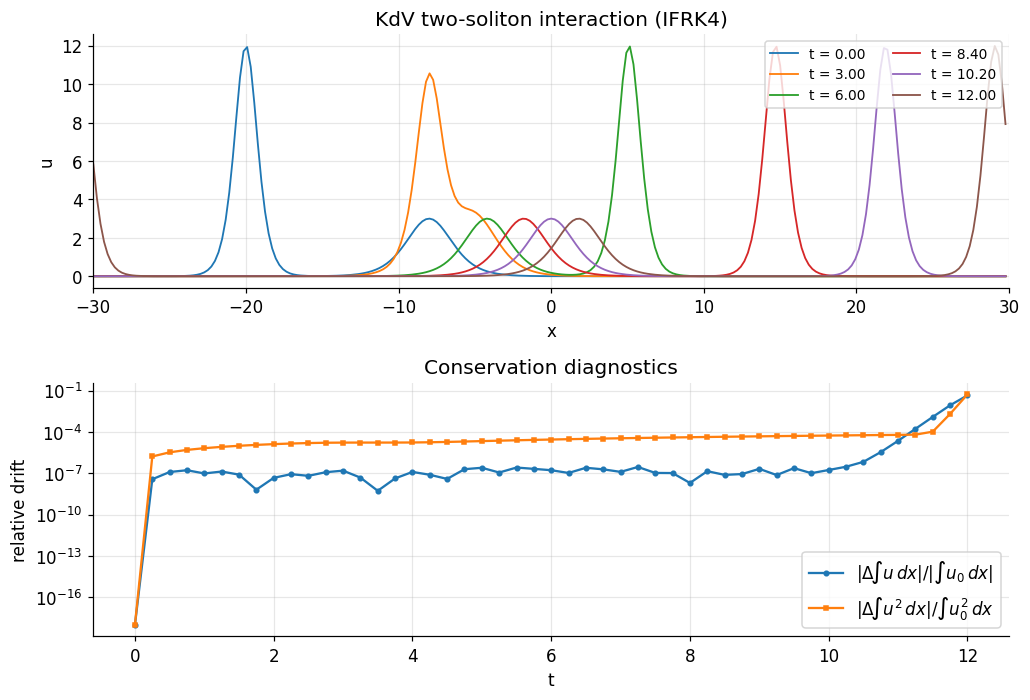

final max-norm of solution: 11.9841


In [7]:
# Domain
L_box = 60.0
N = 256
x = L_box * np.arange(N) / N - L_box / 2          # x in [-L/2, L/2)
k = 2 * np.pi * np.fft.fftfreq(N, d=L_box / N)
ik3 = 1j * k**3

# 2/3 dealiasing mask
dealias_mask = (np.abs(k) <= (2.0 / 3.0) * (N / 2) * (2 * np.pi / L_box)).astype(float)

# Two solitons of speeds c1 > c2, the faster one starting behind the slower one.
def soliton(x, c, x0):
    return 3 * c / np.cosh(np.sqrt(c) / 2 * (x - x0)) ** 2

c1, c2 = 4.0, 1.0
x01, x02 = -20.0, -8.0
u0 = soliton(x, c1, x01) + soliton(x, c2, x02)
v_hat = np.fft.fft(u0)

T = 12.0
dt = 0.005
nsteps = int(round(T / dt))
save_steps = sorted(set([0, int(0.25 * nsteps), int(0.5 * nsteps),
                          int(0.7 * nsteps), int(0.85 * nsteps), nsteps]))
snapshots = {}
mass_hist, energy_hist, t_hist = [], [], []
for n in range(nsteps + 1):
    if n in save_steps:
        u_now = np.real(np.fft.ifft(v_hat))
        snapshots[n * dt] = u_now.copy()
    # diagnostics every 50 steps
    if n % 50 == 0:
        u_now = np.real(np.fft.ifft(v_hat))
        mass_hist.append(np.trapezoid(u_now, x))
        # KdV "energy" int u^2 dx (a conserved quantity)
        energy_hist.append(np.trapezoid(u_now**2, x))
        t_hist.append(n * dt)
    if n < nsteps:
        v_hat = kdv_step_ifrk4(v_hat, dt, k, ik3, dealias_mask)

fig, ax = plt.subplots(2, 1, figsize=(9.5, 6.5))
for t, u_t in snapshots.items():
    ax[0].plot(x, u_t + 0, lw=1.2, label=f"t = {t:.2f}")
ax[0].set_xlim(-L_box / 2, L_box / 2)
ax[0].set_xlabel("x"); ax[0].set_ylabel("u")
ax[0].set_title("KdV two-soliton interaction (IFRK4)")
ax[0].legend(loc="upper right", ncol=2, fontsize=9)

mass_hist = np.array(mass_hist); energy_hist = np.array(energy_hist)
ax[1].plot(t_hist, np.abs(mass_hist - mass_hist[0]) / abs(mass_hist[0]) + 1e-18,
           "o-", ms=3, label=r"$|\Delta\!\int u\,dx| / |\int u_0\,dx|$")
ax[1].plot(t_hist, np.abs(energy_hist - energy_hist[0]) / energy_hist[0] + 1e-18,
           "s-", ms=3, label=r"$|\Delta\!\int u^2\,dx| / \int u_0^2\,dx$")
ax[1].set_yscale("log")
ax[1].set_xlabel("t"); ax[1].set_ylabel("relative drift")
ax[1].set_title("Conservation diagnostics")
ax[1].legend()
plt.tight_layout(); plt.show()

print(f"final max-norm of solution: {np.max(np.abs(np.real(np.fft.ifft(v_hat)))):.4f}")

**What to look for.** The taller (faster, $c_1=4$) soliton catches up to the shorter one,
they merge, and emerge as two solitons with their original shapes — this is the *elastic*
collision that distinguishes solitons from ordinary nonlinear waves. The mass $\int u\,dx$ should
be conserved exactly (it's just $\hat u_0$ times $L$, untouched by the time stepping). The energy
$\int u^2\,dx$ drifts only because of finite $\Delta t$ and dealiasing — drift below
$\sim 10^{-10}$ relative on this run is excellent.

### Why IFRK4 here and not just RK4?

For $N=256$, $L=60$: $k_{\max} = \pi N / L \approx 13.4$, so $k_{\max}^3 \approx 2400$. A vanilla
RK4 stability requires $\Delta t \lesssim 2.78/k_{\max}^3 \approx 1.2\times 10^{-3}$. IFRK4 lifts
that constraint entirely on the linear part — the only remaining $\Delta t$ restriction is from
the *nonlinear* terms, which are much milder.

For genuinely production code, **ETDRK4** (Cox–Matthews; Kassam–Trefethen 2005) is even better — it
also integrates the linear part exactly, but its accuracy on the nonlinear part is fourth order
*regardless* of how large $\hat L\Delta t$ is. IFRK4 only retains true 4th order when $\hat L\Delta t$
is moderate.

## 4. The Gibbs phenomenon and exponential filtering

Pseudospectral accuracy hinges on smoothness. If $u$ has a jump discontinuity, the global
trigonometric (or polynomial) interpolant develops $\mathcal{O}(1)$ overshoots near the jump that
do **not** decrease with $N$ — the **Gibbs phenomenon**. Worse, the error from the jump
contaminates the solution everywhere via "spectral pollution."

### Demonstration: a square wave

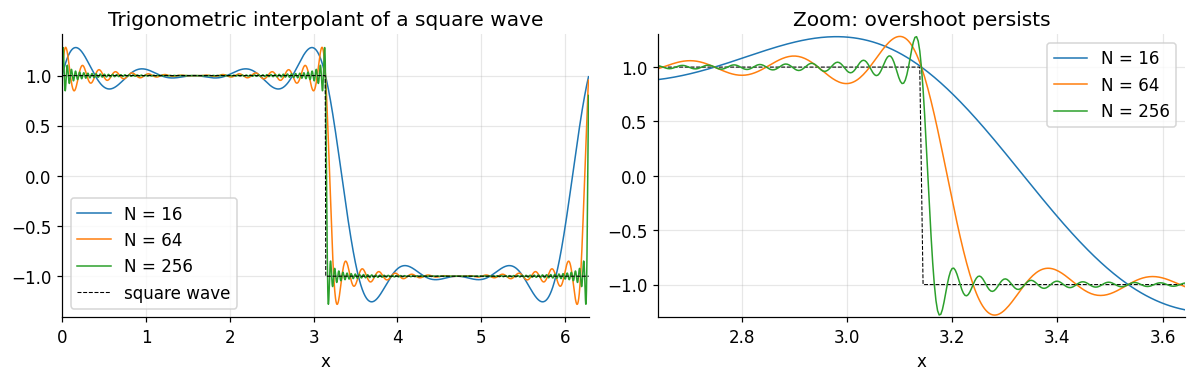

Maximum overshoot of the partial Fourier sum approaches ~9% of the jump as N -> infty
(Gibbs constant: 0.0894898... = (1/pi) * integral_0^pi sinc(t) dt - 1/2)


In [8]:
def square_wave(x):
    return np.where(np.sin(x) >= 0, 1.0, -1.0)


L = 2 * np.pi
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

for N in [16, 64, 256]:
    xj = np.arange(N) * L / N
    uj = square_wave(xj)
    u_hat = np.fft.fft(uj)
    # Evaluate trigonometric interpolant on a fine grid via zero-padding.
    Nfine = 2048
    pad = np.zeros(Nfine, dtype=complex)
    if N % 2 == 0:
        half = N // 2
        pad[:half] = u_hat[:half]
        pad[Nfine - half + 1:] = u_hat[half + 1:]
        # Split Nyquist symmetrically
        pad[half] = 0.5 * u_hat[half]
        pad[Nfine - half] = 0.5 * u_hat[half]
    else:
        half = N // 2
        pad[:half + 1] = u_hat[:half + 1]
        pad[Nfine - half:] = u_hat[half + 1:]
    u_interp = np.real(np.fft.ifft(pad)) * (Nfine / N)
    xfine = np.arange(Nfine) * L / Nfine
    ax[0].plot(xfine, u_interp, lw=1.0, label=f"N = {N}")

ax[0].plot(np.linspace(0, 2 * np.pi, 1000), square_wave(np.linspace(0, 2 * np.pi, 1000)),
           "k--", lw=0.7, label="square wave")
ax[0].set_xlabel("x"); ax[0].set_title("Trigonometric interpolant of a square wave")
ax[0].set_xlim(0, 2 * np.pi); ax[0].legend()

# Zoom near the jump
ax[1].plot(np.linspace(0, 2 * np.pi, 1000), square_wave(np.linspace(0, 2 * np.pi, 1000)),
           "k--", lw=0.7)
for N in [16, 64, 256]:
    xj = np.arange(N) * L / N
    uj = square_wave(xj)
    u_hat = np.fft.fft(uj)
    Nfine = 2048
    pad = np.zeros(Nfine, dtype=complex)
    if N % 2 == 0:
        half = N // 2
        pad[:half] = u_hat[:half]
        pad[Nfine - half + 1:] = u_hat[half + 1:]
        pad[half] = 0.5 * u_hat[half]
        pad[Nfine - half] = 0.5 * u_hat[half]
    else:
        half = N // 2
        pad[:half + 1] = u_hat[:half + 1]
        pad[Nfine - half:] = u_hat[half + 1:]
    u_interp = np.real(np.fft.ifft(pad)) * (Nfine / N)
    xfine = np.arange(Nfine) * L / Nfine
    ax[1].plot(xfine, u_interp, lw=1.0, label=f"N = {N}")

ax[1].set_xlim(np.pi - 0.5, np.pi + 0.5)
ax[1].set_ylim(-1.3, 1.3)
ax[1].set_xlabel("x"); ax[1].set_title("Zoom: overshoot persists")
ax[1].legend()
plt.tight_layout(); plt.show()

print("Maximum overshoot of the partial Fourier sum approaches ~9% of the jump as N -> infty")
print("(Gibbs constant: 0.0894898... = (1/pi) * integral_0^pi sinc(t) dt - 1/2)")

The overshoot doesn't shrink — it's about 8.95 % of the jump no matter how large $N$ gets.
The width of the overshoot region shrinks like $1/N$, but its height does not.

### Spectral filtering

A **filter** multiplies Fourier coefficients by a smooth function $\sigma(\eta)$ where
$\eta = |k|/k_{\max}$, with $\sigma(0)=1$ and $\sigma(1)=0$. A common choice is the
**exponential** filter

$$
\sigma_\alpha^{(p)}(\eta) = \exp\!\left(-\alpha\,\eta^p\right),
$$

with $p$ even (typical: $p=8,10,12$), and $\alpha$ chosen so that $\sigma(1) \approx \epsilon_\mathrm{mach}$
(i.e., $\alpha \approx 36$ for double precision). Filtering does *not* recover spectral accuracy
near the jump — that's a fundamental limitation — but it removes the spectral pollution and
restores high accuracy *away* from the jump.

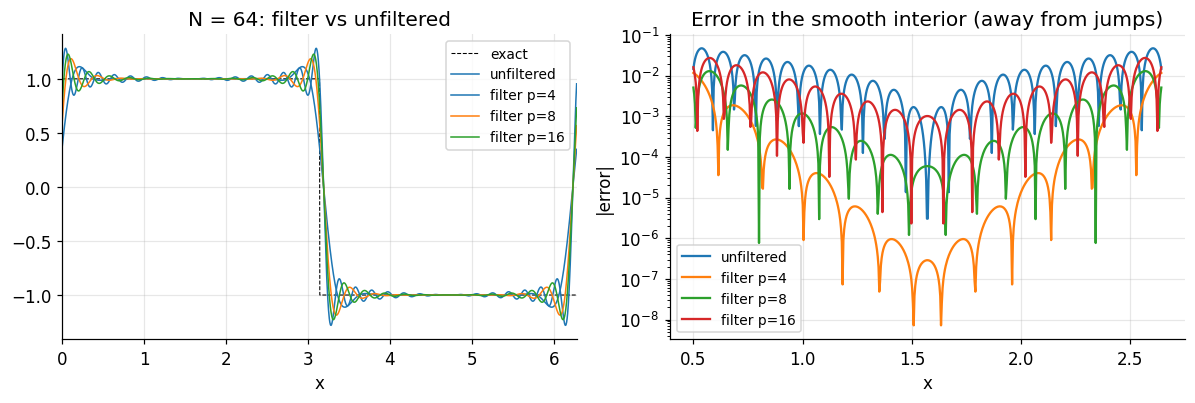

In [9]:
def exp_filter(N, p=10, alpha=36.0):
    '''Exponential filter on Fourier coefficients in DFT order.'''
    k = np.fft.fftfreq(N, d=1.0) * N             # raw mode index, signed
    eta = np.abs(k) / (N / 2)                    # normalized to [0, 1]
    return np.exp(-alpha * eta**p)


N = 64
xj = np.arange(N) * L / N
uj = square_wave(xj)
u_hat = np.fft.fft(uj)

xfine = np.linspace(0, L, 2000, endpoint=False)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

# Unfiltered partial-sum interpolant
def trig_interp(u_hat_in, xfine, N, L):
    out = np.zeros_like(xfine)
    half = N // 2
    for m in range(-half + 1, half + 1):
        idx = m % N
        if N % 2 == 0 and m == half:
            out += np.real(0.5 * u_hat_in[idx] * np.exp(1j * m * 2 * np.pi / L * xfine)) / N
            out += np.real(0.5 * u_hat_in[idx] * np.exp(-1j * m * 2 * np.pi / L * xfine)) / N
        else:
            out += np.real(u_hat_in[idx] * np.exp(1j * m * 2 * np.pi / L * xfine)) / N
    return out

ax[0].plot(xfine, square_wave(xfine), "k--", lw=0.7, label="exact")
ax[0].plot(xfine, trig_interp(u_hat, xfine, N, L), "C0", lw=1, label="unfiltered")
for p in (4, 8, 16):
    sigma = exp_filter(N, p=p)
    ax[0].plot(xfine, trig_interp(u_hat * sigma, xfine, N, L), lw=1, label=f"filter p={p}")
ax[0].set_xlim(0, 2 * np.pi); ax[0].set_xlabel("x")
ax[0].set_title(f"N = {N}: filter vs unfiltered"); ax[0].legend(fontsize=9)

# Pointwise error away from the jump
xq = np.linspace(0.5, np.pi - 0.5, 600)         # away from x = 0, pi (jumps)
err_unfilt = np.abs(trig_interp(u_hat, xq, N, L) - square_wave(xq))
ax[1].semilogy(xq, np.maximum(err_unfilt, 1e-18), label="unfiltered")
for p in (4, 8, 16):
    sigma = exp_filter(N, p=p)
    err_p = np.abs(trig_interp(u_hat * sigma, xq, N, L) - square_wave(xq))
    ax[1].semilogy(xq, np.maximum(err_p, 1e-18), label=f"filter p={p}")
ax[1].set_xlabel("x"); ax[1].set_ylabel("|error|")
ax[1].set_title("Error in the smooth interior (away from jumps)")
ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

**The takeaway.** Filtering trades a slight smoothing of the jump for cleaner behavior in the
smooth regions. Larger $p$ keeps more of the high modes (preserving sharpness) but lets through more
oscillation; smaller $p$ smooths more aggressively. In time-stepping a nonlinear PDE, applying a
mild filter every few steps is often the difference between a long stable run and a blow-up.

There are more sophisticated post-processing techniques — *Gegenbauer reconstruction* and
*spectral mollifiers* — that can restore high-order accuracy *up to the jump location*, given
extra information (e.g. that $u$ is piecewise smooth). They're outside scope here; see
Hesthaven, Gottlieb, & Gottlieb (2007) or Tadmor's review papers.

## 5. Where to go next: spectral elements

Pseudospectral methods are gloriously efficient on tensor-product domains with smooth solutions.
They struggle when:

* the geometry isn't a box / disk / sphere with a clean analytic mapping;
* you need local refinement (a sharp feature in one part of the domain);
* there are interface conditions or piecewise materials.

The standard answer is the **spectral element method (SEM)**: tile the domain with curvilinear
quadrilateral or hexahedral "elements," put a small Chebyshev or Legendre grid on each, enforce
$C^0$ continuity at element interfaces (continuous Galerkin) or weak compatibility (discontinuous
Galerkin / DG-SEM). On each element the convergence is still spectral in the local polynomial
order; refinement is local; geometry is flexible.

A few pointers if you want to go deeper:

* M. O. Deville, P. F. Fischer, E. H. Mund, *High-Order Methods for Incompressible Fluid Flow*
  (CUP, 2002) — the standard SEM reference.
* G. Karniadakis & S. Sherwin, *Spectral/hp Element Methods for CFD*, 2nd ed. (OUP, 2005).
* J. S. Hesthaven & T. Warburton, *Nodal Discontinuous Galerkin Methods* (Springer, 2008) — for DG.
* Open-source production codes: **Nek5000** / **NekRS** (incompressible Navier–Stokes, SEM),
  **Nektar++** (general spectral/hp), **PyFR** (compressible flux reconstruction, GPU-native).

For *time-stepping* on stiff PDEs, the natural follow-up to IFRK4 is **ETDRK4** (Cox–Matthews 2002,
with the Kassam–Trefethen 2005 contour-integral evaluation of the $\varphi$-functions). It is the
standard recommendation when you need fourth-order time accuracy on a problem with a stiff linear
part of any size.

For *fast* Chebyshev/Fourier transforms in production: every Chebyshev operation has an
$\mathcal{O}(N\log N)$ implementation via the DCT / DST. The dense $D$-matrix-vector multiply we
used here is $\mathcal{O}(N^2)$ — fine for $N \lesssim 1000$, but fast transforms are essential
beyond that. Look at FFTW's `REDFT` / `RODFT` kinds, or numpy's `scipy.fft.dct`.